# Simple Linear Regression — Gradient Descent from Scratch

**Goal:** Fit `y = w*x + b` using batch gradient descent, and compare with `sklearn.LinearRegression`.

**Loss function (MSE):**
$$J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}(\hat{y}_i - y_i)^2 \quad,\quad \hat{y}_i = wx_i+b$$

**Gradients:**
$$\frac{\partial J}{\partial w} = \frac{1}{m}\sum (\hat{y}_i-y_i)x_i \qquad \frac{\partial J}{\partial b} = \frac{1}{m}\sum (\hat{y}_i-y_i)$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

## 1. Dataset
Synthetic single-feature dataset: `y = 4 + 3x + noise` (e.g. experience-vs-salary style).

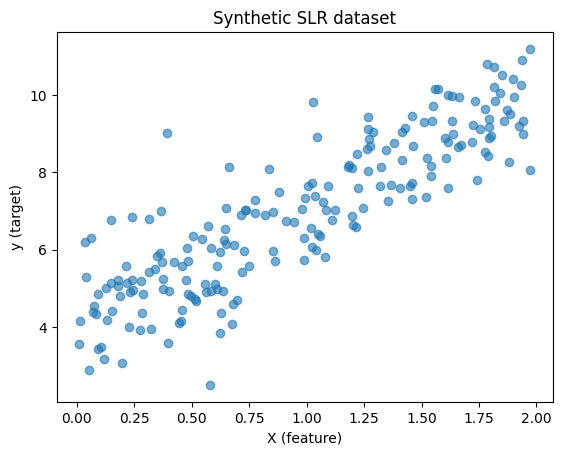

In [2]:
m = 200
X = 2 * np.random.rand(m, 1)          # feature, shape (m,1)
y = 4 + 3 * X + np.random.randn(m, 1) # true relation with noise

plt.scatter(X, y, alpha=0.6)
plt.xlabel("X (feature)"); plt.ylabel("y (target)")
plt.title("Synthetic SLR dataset")
plt.show()

X_flat = X.flatten()
y_flat = y.flatten()

## 2. Loss function (MSE)

In [3]:
def compute_loss(X, y, w, b):
    m = len(y)
    y_pred = w * X + b
    return (1/(2*m)) * np.sum((y_pred - y) ** 2)

## 3. Gradient Descent implementation

In [4]:
def gradient_descent_slr(X, y, lr=0.1, epochs=1000):
    m = len(y)
    w, b = 0.0, 0.0
    loss_history = []

    for i in range(epochs):
        y_pred = w * X + b
        error = y_pred - y

        dw = (1/m) * np.sum(error * X)
        db = (1/m) * np.sum(error)

        w -= lr * dw
        b -= lr * db

        loss = compute_loss(X, y, w, b)
        loss_history.append(loss)

        if i % 100 == 0:
            print(f"Epoch {i:4d} | loss={loss:.4f} | w={w:.4f} | b={b:.4f}")

    return w, b, loss_history

w, b, loss_history = gradient_descent_slr(X_flat, y_flat, lr=0.5, epochs=1000)
print(f"\nFinal params -> w={w:.4f}, b={b:.4f}")

Epoch    0 | loss=0.6534 | w=3.8866 | b=3.4857
Epoch  100 | loss=0.4669 | w=2.9611 | b=4.1050
Epoch  200 | loss=0.4669 | w=2.9610 | b=4.1052
Epoch  300 | loss=0.4669 | w=2.9610 | b=4.1052
Epoch  400 | loss=0.4669 | w=2.9610 | b=4.1052
Epoch  500 | loss=0.4669 | w=2.9610 | b=4.1052
Epoch  600 | loss=0.4669 | w=2.9610 | b=4.1052
Epoch  700 | loss=0.4669 | w=2.9610 | b=4.1052
Epoch  800 | loss=0.4669 | w=2.9610 | b=4.1052
Epoch  900 | loss=0.4669 | w=2.9610 | b=4.1052

Final params -> w=2.9610, b=4.1052


## 4. Convergence plot

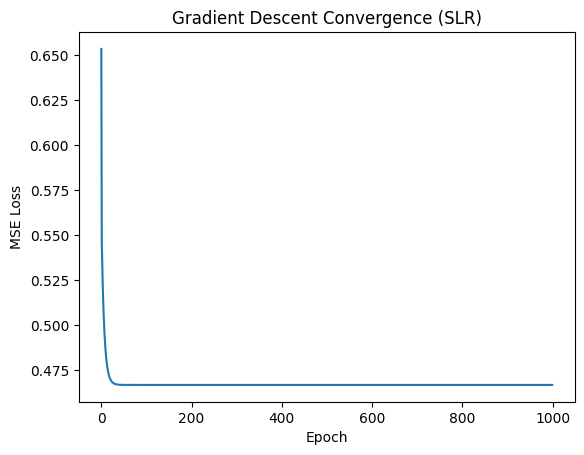

In [5]:
plt.plot(loss_history)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Gradient Descent Convergence (SLR)")
plt.show()

## 5. Fitted line vs data

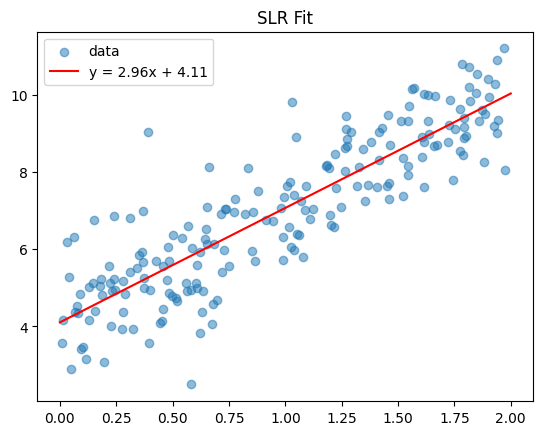

In [6]:
plt.scatter(X_flat, y_flat, alpha=0.5, label="data")
x_line = np.linspace(0, 2, 100)
plt.plot(x_line, w * x_line + b, color="red", label=f"y = {w:.2f}x + {b:.2f}")
plt.legend(); plt.title("SLR Fit"); plt.show()

## 6. Compare with sklearn

In [7]:
model = LinearRegression()
model.fit(X, y)
print("sklearn coef:", model.coef_[0][0], "| intercept:", model.intercept_[0])
print("scratch     :", w, "|", b)

y_pred_scratch = w * X_flat + b
print("\nScratch MSE:", mean_squared_error(y_flat, y_pred_scratch))
print("sklearn MSE :", mean_squared_error(y, model.predict(X)))

sklearn coef: 2.9609644659125136 | intercept: 4.1052011509608235
scratch     : 2.960964465912515 | 4.105201150960821

Scratch MSE: 0.9338262007909794
sklearn MSE : 0.9338262007909797


## 7. Try it yourself
- Change `lr` (learning rate) to 0.01 and 1.0 — what happens to convergence?
- Implement **stochastic** and **mini-batch** gradient descent variants.
- Add a real dataset (e.g. study hours vs marks) and refit.
